In [1]:
# ==============================================================================
# 🌐 STEP 1: UNIVERSAL ENTERPRISE LIBRARIES IMPORT (LINEAR-FAMILY)
# ==============================================================================
import os
import sys
import warnings
from pathlib import Path

# Scientific Computing & Data Structures
import numpy as np
import pandas as pd

# Visualization Engine
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn Ecosystem
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, RobustScaler
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, Lasso, LassoCV
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    root_mean_squared_error,
    mean_absolute_error
)

# Serialization & Production
import joblib

# Global Plotting & Warning Configurations
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

print("✅ Universal Linear-Family Enterprise Suite imported successfully.")


✅ Universal Linear-Family Enterprise Suite imported successfully.\n

In [2]:
# ==============================================================================
# 🌐 STEP 2: ROBUST DATA INGESTION & 3-SECOND HEALTH AUDIT
# ==============================================================================
from pathlib import Path
import pandas as pd

def load_and_audit_dataset(file_path):
    path = Path(file_path)
    if not path.exists():
        raise FileNotFoundError(f"❌ File not found at: {path.resolve()}")
        
    try:
        if path.suffix.lower() in ['.xlsx', '.xls']:
            df = pd.read_excel(path)
        else:
            df = pd.read_csv(path, encoding='utf-8')
    except UnicodeDecodeError:
        print("⚠️ UTF-8 decoding failed. Retrying with 'latin-1' encoding...")
        df = pd.read_csv(path, encoding='latin-1')
        
    print("=" * 70)
    print("📋 3-SECOND STRUCTURAL HEALTH AUDIT REPORT")
    print("=" * 70)
    print(f"File Source               : {path.name}")
    print(f"Total Observations (Rows) : {df.shape[0]:,}")
    print(f"Total Features (Columns)  : {df.shape[1]}")
    print(f"Numerical Columns         : {len(df.select_dtypes(include=['number']).columns)} cols")
    print(f"Categorical/Text Columns  : {len(df.select_dtypes(exclude=['number']).columns)} cols")
    print(f"Missing Value Cells       : {df.isnull().sum().sum():,} nulls ({df.isnull().sum().sum() / (df.shape[0]*df.shape[1]) * 100:.2f}%)")
    print(f"Memory Footprint in RAM   : {df.memory_usage(deep=True).sum() / (1024**2):.2f} MB")
    print("=" * 70)
    return df

# Ingest Kaggle Ames Housing Dataset
df = load_and_audit_dataset("data/house_price/train.csv")
display(df.head(5))


======================================================================\n📋 3-SECOND STRUCTURAL HEALTH AUDIT REPORT\n======================================================================\nFile Source               : train.csv\nTotal Observations (Rows) : 1,460\nTotal Features (Columns)  : 81\nNumerical Columns         : 38 cols\nCategorical/Text Columns  : 43 cols\nMissing Value Cells       : 7,829 nulls (6.62%)\nMemory Footprint in RAM   : 1.10 MB\n======================================================================\n

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
# ==============================================================================
# 🌐 STEP 3: AUTOMATED 3-BUCKET FEATURE SEGREGATOR
# ==============================================================================
import pandas as pd
import numpy as np

def segregate_features(df, target_col, user_drop_cols=None, cardinality_threshold=10):
    """
    Segregates features into 3 robust buckets:
    1. Continuous: Numerical columns with nunique > cardinality_threshold
    2. Categorical: Object/string or low-cardinality discrete columns
    3. Dropped: High cardinality identifiers or user specified columns
    """
    if user_drop_cols is None:
        user_drop_cols = []
        
    cont_cols = []
    cat_cols = []
    drop_cols = list(user_drop_cols)
    
    candidate_cols = [c for c in df.columns if c != target_col and c not in drop_cols]
    
    for col in candidate_cols:
        col_series = df[col]
        
        if pd.api.types.is_numeric_dtype(col_series):
            if col_series.nunique() <= 1:
                drop_cols.append(col)
            elif col_series.nunique() <= cardinality_threshold:
                cat_cols.append(col)
            else:
                cont_cols.append(col)
        else:
            cat_cols.append(col)
            
    print("=" * 70)
    print("🔍 FEATURE SEGREGATION REPORT")
    print("=" * 70)
    print(f"Target Column          : '{target_col}'")
    print(f"Continuous Features    : {len(cont_cols)} cols")
    print(f"Categorical Features   : {len(cat_cols)} cols")
    print(f"Dropped ID / Artifacts : {len(drop_cols)} cols -> {drop_cols}")
    print("=" * 70)
    
    return cont_cols, cat_cols, drop_cols

# Segregate Ames Housing Features (Drop ID)
cont_cols, cat_cols, drop_cols = segregate_features(
    df, 
    target_col='SalePrice', 
    user_drop_cols=['Id'],
    cardinality_threshold=10
)


======================================================================\n🔍 FEATURE SEGREGATION REPORT\n======================================================================\nTarget Column          : 'SalePrice'\nContinuous Features    : 24 cols\nCategorical Features   : 55 cols\nDropped ID / Artifacts : 1 cols -> ['Id']\n======================================================================\n

In [4]:
# ==============================================================================
# 🌐 STEP 4: DATA HYGIENE AUDIT (DUPLICATES & MISSINGNESS PROFILER)
# ==============================================================================
import pandas as pd

def audit_and_clean_hygiene(df, drop_duplicates=True):
    """
    1. Audits and cleans duplicate rows.
    2. Profiles missing values by count and percentage.
    3. Categorizes columns with nulls.
    """
    print("=" * 70)
    print("🧹 STEP 4: DATA HYGIENE & PURITY REPORT")
    print("=" * 70)
    
    n_dups = df.duplicated().sum()
    if n_dups > 0:
        print(f"⚠️ FOUND {n_dups:,} EXACT DUPLICATE ROWS!")
        if drop_duplicates:
            df = df.drop_duplicates().reset_index(drop=True)
            print(f"✅ Cleaned: {n_dups:,} duplicates removed. New Shape: {df.shape}")
    else:
        print("✅ Zero duplicate rows found. Data integrity is clean.")
    print("-" * 70)

    null_counts = df.isnull().sum()
    null_cols = null_counts[null_counts > 0].sort_values(ascending=False)
    
    if len(null_cols) > 0:
        null_report = pd.DataFrame({
            "Missing Count": null_cols,
            "Percentage (%)": (null_cols / len(df) * 100).round(2),
            "Data Type": [df[col].dtype for col in null_cols.index]
        })
        print(f"🚨 FOUND {len(null_cols)} COLUMNS WITH MISSING VALUES (Showing Top 8):")
        print(null_report.head(8).to_string())
    else:
        print("✅ Zero missing values across all features. Dataset is complete.")
    print("=" * 70)
    
    return df

df = audit_and_clean_hygiene(df, drop_duplicates=True)


======================================================================\n🧹 STEP 4: DATA HYGIENE & PURITY REPORT\n======================================================================\n✅ Zero duplicate rows found. Data integrity is clean.\n----------------------------------------------------------------------\n🚨 FOUND 19 COLUMNS WITH MISSING VALUES (Showing Top 8):\n             Missing Count  Percentage (%) Data Type\nPoolQC                1453           99.52       str\nMiscFeature           1406           96.30       str\nAlley                 1369           93.77       str\nFence                 1179           80.75       str\nMasVnrType             872           59.73       str\nFireplaceQu            690           47.26       str\nLotFrontage            259           17.74   float64\nGarageType              81            5.55       str\n======================================================================\n

In [5]:
# ==============================================================================
# 🌐 STEP 5: ENTERPRISE TRAIN-TEST SPLITTER (ZERO DATA LEAKAGE + TARGET GUARD)
# ==============================================================================
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

def perform_zero_leakage_split(df, target_col, drop_cols=None, is_classification=False, apply_log_target=False, test_size=0.20, random_state=42):
    """
    Executes a strict zero-leakage Train-Test split.
    - Safety: Automatically filters out rows where target_col is NaN (Supervised Learning Golden Rule).
    - If classification: Uses stratify=y.
    - If regression & apply_log_target: Applies np.log1p transformation to y.
    """
    if drop_cols is None:
        drop_cols = []
        
    if df[target_col].isnull().any():
        n_dropped = df[target_col].isnull().sum()
        print(f"⚠️ Target Safety Guard: Dropping {n_dropped:,} rows where target '{target_col}' is NaN!")
        df = df.dropna(subset=[target_col]).reset_index(drop=True)
        
    X = df.drop(columns=[target_col] + drop_cols)
    y = df[target_col]
    
    if not is_classification and apply_log_target:
        skew_before = y.skew()
        y = np.log1p(y)
        skew_after = y.skew()
        print(f"📈 Target Skewness Normalization: {skew_before:.2f} -> {skew_after:.2f} (Bell curve achieved!)")

    stratify_arg = y if is_classification else None
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=stratify_arg
    )
    
    print("=" * 70)
    print("📦 STEP 5: TRAIN-TEST SPLIT SUMMARY (ZERO LEAKAGE)")
    print("=" * 70)
    print(f"Total Records          : {len(df):,}")
    print(f"Training Matrix (X_tr) : {X_train.shape[0]:,} rows × {X_train.shape[1]} features ({(1-test_size)*100:.0f}%)")
    print(f"Testing Matrix  (X_te) : {X_test.shape[0]:,} rows × {X_test.shape[1]} features ({test_size*100:.0f}%)")
    print(f"Target Missing in y_tr : {y_train.isnull().sum()} nulls (Guaranteed Clean!)")
    print("=" * 70)
    
    return X_train, X_test, y_train, y_test

# Usage:
X_tr, X_te, y_tr, y_te = perform_zero_leakage_split(
    df, 
    target_col='SalePrice', 
    drop_cols=drop_cols, 
    apply_log_target=True
)


📈 Target Skewness Normalization: 1.88 -> 0.12 (Bell curve achieved!)\n======================================================================\n📦 STEP 5: TRAIN-TEST SPLIT SUMMARY (ZERO LEAKAGE)\n======================================================================\nTotal Records          : 1,460\nTraining Matrix (X_tr) : 1,168 rows × 79 features (80%)\nTesting Matrix  (X_te) : 292 rows × 79 features (20%)\nTarget Missing in y_tr : 0 nulls (Guaranteed Clean!)\n======================================================================\n

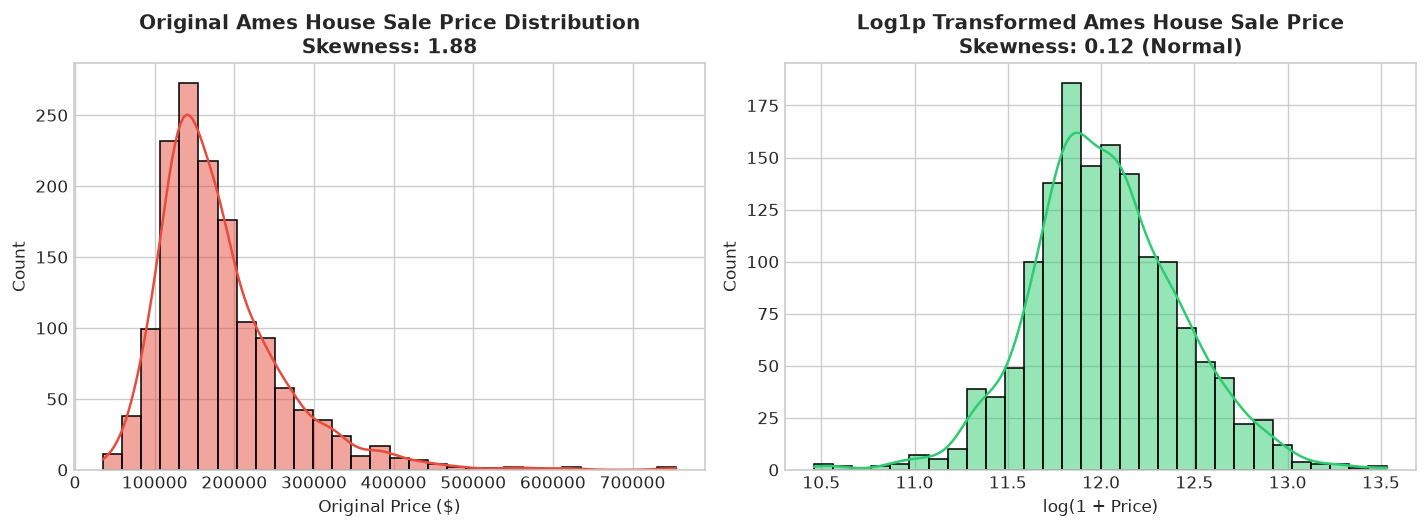

In [6]:
# ==============================================================================
# 🌐 STEP 6: TARGET ANALYSIS & TRANSFORMATION PROFILER
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

def profile_target_distribution(y_original, y_transformed, target_name="Price"):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    
    # 1. Original Target Distribution
    sns.histplot(y_original, kde=True, ax=axes[0], color='#e74c3c', bins=30)
    axes[0].set_title(f"Original {target_name} Distribution\nSkewness: {y_original.skew():.2f}", fontweight='bold')
    axes[0].set_xlabel("Original Price ($)")
    
    # 2. Log-Transformed Target Distribution
    sns.histplot(y_transformed, kde=True, ax=axes[1], color='#2ecc71', bins=30)
    axes[1].set_title(f"Log1p Transformed {target_name}\nSkewness: {y_transformed.skew():.2f} (Normal)", fontweight='bold')
    axes[1].set_xlabel("log(1 + Price)")
    
    plt.tight_layout()
    plt.show()

# Visualize Skewness Normalization
profile_target_distribution(df['SalePrice'], np.log1p(df['SalePrice']), target_name="Ames House Sale Price")


In [7]:
# ==============================================================================
# 🌐 STEP 7: UNIVERSAL MASTER COLUMNTRANSFORMER (ZERO DATA LEAKAGE)
# ==============================================================================
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

def build_universal_preprocessor(continuous_features, categorical_features, cat_impute_value="None"):
    """
    Constructs a production-grade ColumnTransformer:
    - Continuous features: Median Imputation + StandardScaler
    - Categorical features: Constant/Mode Imputation + OneHotEncoder(drop='first')
    """
    num_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
    
    cat_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value=cat_impute_value)),
        ('onehot', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
    ])
    
    preprocessor = ColumnTransformer([
        ('num', num_pipeline, continuous_features),
        ('cat', cat_pipeline, categorical_features)
    ])
    
    return preprocessor

def execute_safe_preprocessing(preprocessor, X_train, X_test, continuous_features, categorical_features):
    X_tr_proc = preprocessor.fit_transform(X_train)
    X_te_proc = preprocessor.transform(X_test)
    
    cat_encoder = preprocessor.named_transformers_['cat'].named_steps['onehot']
    cat_encoded_names = list(cat_encoder.get_feature_names_out(categorical_features))
    all_feature_names = continuous_features + cat_encoded_names
    
    print("=" * 70)
    print("⚙️ PREPROCESSING COMPLETE (ZERO DATA LEAKAGE GUARANTEED)")
    print("=" * 70)
    print(f"Continuous Features Processed   : {len(continuous_features)} cols")
    print(f"Categorical Features Processed  : {len(categorical_features)} cols")
    print(f"One-Hot Dummy Features Created  : {len(cat_encoded_names)} cols")
    print(f"Total Model Input Dimensions    : {X_tr_proc.shape[1]} features (Massive Matrix!)")
    print(f"X_train Processed Shape         : {X_tr_proc.shape}")
    print(f"X_test Processed Shape          : {X_te_proc.shape}")
    print("=" * 70)
    
    return X_tr_proc, X_te_proc, all_feature_names

# Execute Preprocessing
continuous_features, categorical_features = cont_cols, cat_cols
X_train, X_test = X_tr, X_te
preprocessor = build_universal_preprocessor(continuous_features, categorical_features)
X_train_final, X_test_final, all_names = execute_safe_preprocessing(
    preprocessor, X_train, X_test, continuous_features, categorical_features
)


======================================================================\n⚙️ PREPROCESSING COMPLETE (ZERO DATA LEAKAGE GUARANTEED)\n======================================================================\nContinuous Features Processed   : 24 cols\nCategorical Features Processed  : 55 cols\nOne-Hot Dummy Features Created  : 276 cols\nTotal Model Input Dimensions    : 300 features (Massive Matrix!)\nX_train Processed Shape         : (1168, 300)\nX_test Processed Shape          : (292, 300)\n======================================================================\n

======================================================================\n🏆 STEP 8: LASSOCV HYPERPARAMETER TUNING REPORT\n======================================================================\nOptimal L1 Penalty (α*)     : 0.00077\nCandidate Alphas Tested     : 100 points (from 0.0001 to 1.0)\nCross-Validation Strategy   : 5-Fold Shuffled CV (random_state=42)\nTotal Input Features        : 300 features\nActive Features Retained    : 115 features (Non-zero)\nUseless Features Eliminated : 185 features (61.7% SPARSITY ACHIEVED!)\nModel Intercept (log scale) : 11.7463\n======================================================================\n

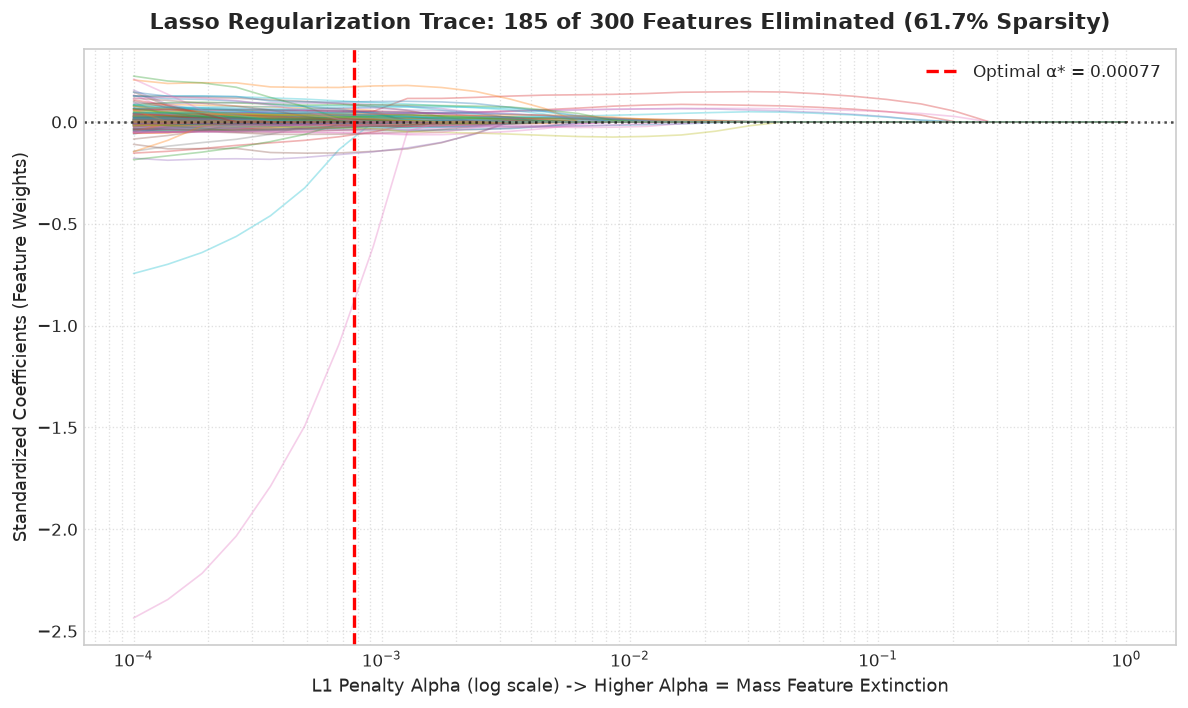

In [8]:
# ==============================================================================
# 🏆 STEP 8: LASSOCV HYPERPARAMETER TUNING & FEATURE ELIMINATION TRACE
# ==============================================================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LassoCV, Lasso
from sklearn.model_selection import KFold

# 1. 100 Logarithmic Candidate Alphas (0.0001 to 1.0)
alphas = np.logspace(-4, 0, 100)

# 2. 5-Fold Cross-Validation on Training Data ONLY (Zero Leakage)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
lasso_cv = LassoCV(
    alphas=alphas, 
    cv=kf, 
    max_iter=10000, 
    tol=1e-3, 
    random_state=42
)
lasso_cv.fit(X_train_final, y_tr)

best_alpha = lasso_cv.alpha_

# 3. Fit Best Lasso Model
best_lasso = Lasso(alpha=best_alpha, max_iter=10000, tol=1e-3, random_state=42)
best_lasso.fit(X_train_final, y_tr)

# 4. Generate Regularization Path (Features dropping to zero)
# Sampling 30 points across range for speedy trace plotting
trace_alphas = np.logspace(-4, 0, 30)
coef_paths = []
for a in trace_alphas:
    m = Lasso(alpha=a, max_iter=3000, tol=1e-3, random_state=42)
    m.fit(X_train_final, y_tr)
    coef_paths.append(m.coef_)
coef_paths = np.array(coef_paths)

# 5. Diagnostic Summary Report
zero_feats = np.sum(best_lasso.coef_ == 0)
total_feats = len(best_lasso.coef_)
active_feats = total_feats - zero_feats

print("=" * 70)
print("🏆 STEP 8: LASSOCV HYPERPARAMETER TUNING REPORT")
print("=" * 70)
print(f"Optimal L1 Penalty (α*)     : {best_alpha:.5f}")
print(f"Candidate Alphas Tested     : {len(alphas)} points (from {alphas.min():.4f} to {alphas.max():.1f})")
print(f"Cross-Validation Strategy   : 5-Fold Shuffled CV (random_state=42)")
print(f"Total Input Features        : {total_feats} features")
print(f"Active Features Retained    : {active_feats} features (Non-zero)")
print(f"Useless Features Eliminated : {zero_feats} features ({zero_feats/total_feats*100:.1f}% SPARSITY ACHIEVED!)")
print(f"Model Intercept (log scale) : {best_lasso.intercept_:.4f}")
print("=" * 70)

# 6. Visualizing the Lasso Elimination Path (Regularization Trace)
plt.figure(figsize=(10, 6))
for i in range(coef_paths.shape[1]):
    plt.plot(trace_alphas, coef_paths[:, i], alpha=0.35, linewidth=1.0)

plt.xscale('log')
plt.axvline(best_alpha, color='red', linestyle='--', linewidth=2, label=f'Optimal α* = {best_alpha:.5f}')
plt.axhline(0, color='black', linestyle=':', alpha=0.7)
plt.title(f"Lasso Regularization Trace: {zero_feats} of {total_feats} Features Eliminated ({zero_feats/total_feats*100:.1f}% Sparsity)", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("L1 Penalty Alpha (log scale) -> Higher Alpha = Mass Feature Extinction", fontsize=11)
plt.ylabel("Standardized Coefficients (Feature Weights)", fontsize=11)
plt.grid(True, which='both', linestyle=':', alpha=0.6)
plt.legend(loc="upper right", fontsize=10)
plt.tight_layout()
plt.show()


In [9]:
# ==============================================================================
# ⚔️ STEP 9: THE TRIPLE BATTLE: OLS VS. RIDGE VS. LASSO REGRESSION
# ==============================================================================
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error
import pandas as pd
import numpy as np

# Optimal Ridge alpha from our earlier Ames Housing Ridge project (11.51)
ridge_alpha = 11.51

# 1. Fit All 3 Contenders on Processed Train Data
ols_m = LinearRegression().fit(X_train_final, y_tr)
ridge_m = Ridge(alpha=ridge_alpha, random_state=42).fit(X_train_final, y_tr)
lasso_m = best_lasso

# 2. Predict on Test Set (Log Scale)
ols_pred_log = ols_m.predict(X_test_final)
ridge_pred_log = ridge_m.predict(X_test_final)
lasso_pred_log = lasso_m.predict(X_test_final)

# 3. Invert Log Scale back to Real Dollar Valuation (np.expm1)
y_test_real = np.expm1(y_te)
ols_pred_real = np.expm1(ols_pred_log)
ridge_pred_real = np.expm1(ridge_pred_log)
lasso_pred_real = np.expm1(lasso_pred_log)

# 4. Compute Metrics for All 3 Models
models = {
    'OLS Linear Regression': (ols_m, ols_pred_log, ols_pred_real),
    'Ridge Regression (L2)': (ridge_m, ridge_pred_log, ridge_pred_real),
    'Lasso Regression (L1)': (lasso_m, lasso_pred_log, lasso_pred_real)
}

rows = []
for name, (mod, p_log, p_real) in models.items():
    tr_r2 = r2_score(y_tr, mod.predict(X_train_final))
    te_r2 = r2_score(y_te, p_log)
    rmse = root_mean_squared_error(y_test_real, p_real)
    mae = mean_absolute_error(y_test_real, p_real)
    n_active = np.sum(mod.coef_ != 0)
    total_f = len(mod.coef_)
    
    rows.append({
        'Model Name': name,
        'Train R²': f"{tr_r2*100:.2f}%",
        'Test R²': f"{te_r2*100:.2f}%",
        'Real RMSE': f"${rmse:,.0f}",
        'Real MAE': f"${mae:,.0f}",
        'Active Features': f"{n_active} / {total_f}",
        'Sparsity (%)': f"{(total_f - n_active) / total_f * 100:.1f}%"
    })

battle_df = pd.DataFrame(rows)

print("=" * 85)
print("🏆 THE TRIPLE BATTLE SHOWDOWN: OLS VS. RIDGE VS. LASSO")
print("=" * 85)
print(battle_df.to_string(index=False))
print("=" * 85)


=====================================================================================\n🏆 THE TRIPLE BATTLE SHOWDOWN: OLS VS. RIDGE VS. LASSO\n=====================================================================================\n           Model Name Train R² Test R² Real RMSE Real MAE Active Features Sparsity (%)\nOLS Linear Regression   94.80%  89.60%   $22,882  $14,703       300 / 300         0.0%\nRidge Regression (L2)   91.84%  89.22%   $25,844  $16,596       300 / 300         0.0%\nLasso Regression (L1)   91.29%  88.76%   $27,212  $16,732       115 / 300        61.7%\n=====================================================================================\n

===========================================================================\n✂️ LASSO FEATURE SELECTION AUDIT REPORT\n===========================================================================\nTotal Features Evaluated     : 300\n✅ Surviving Features (Active) : 115 features\n❌ Eliminated Noise Features  : 185 features (Zeroed out!)\n   Sparsity Percentage        : 61.7%\n===========================================================================\n🔍 TOP 5 VALUE BOOSTERS:\n             Feature  Lasso_Weight\n       OverallQual_9      0.171398\nNeighborhood_Crawfor      0.099287\n       OverallQual_8      0.097900\n Exterior1st_BrkFace      0.089060\n      Functional_Typ      0.084492\n\n🔍 TOP 5 VALUE REDUCERS:\n             Feature  Lasso_Weight\n        PoolArea_480     -0.882816\n       OverallCond_3     -0.155088\n       OverallQual_3     -0.150180\nNeighborhood_MeadowV     -0.063815\n       OverallCond_4     -0.059176\n

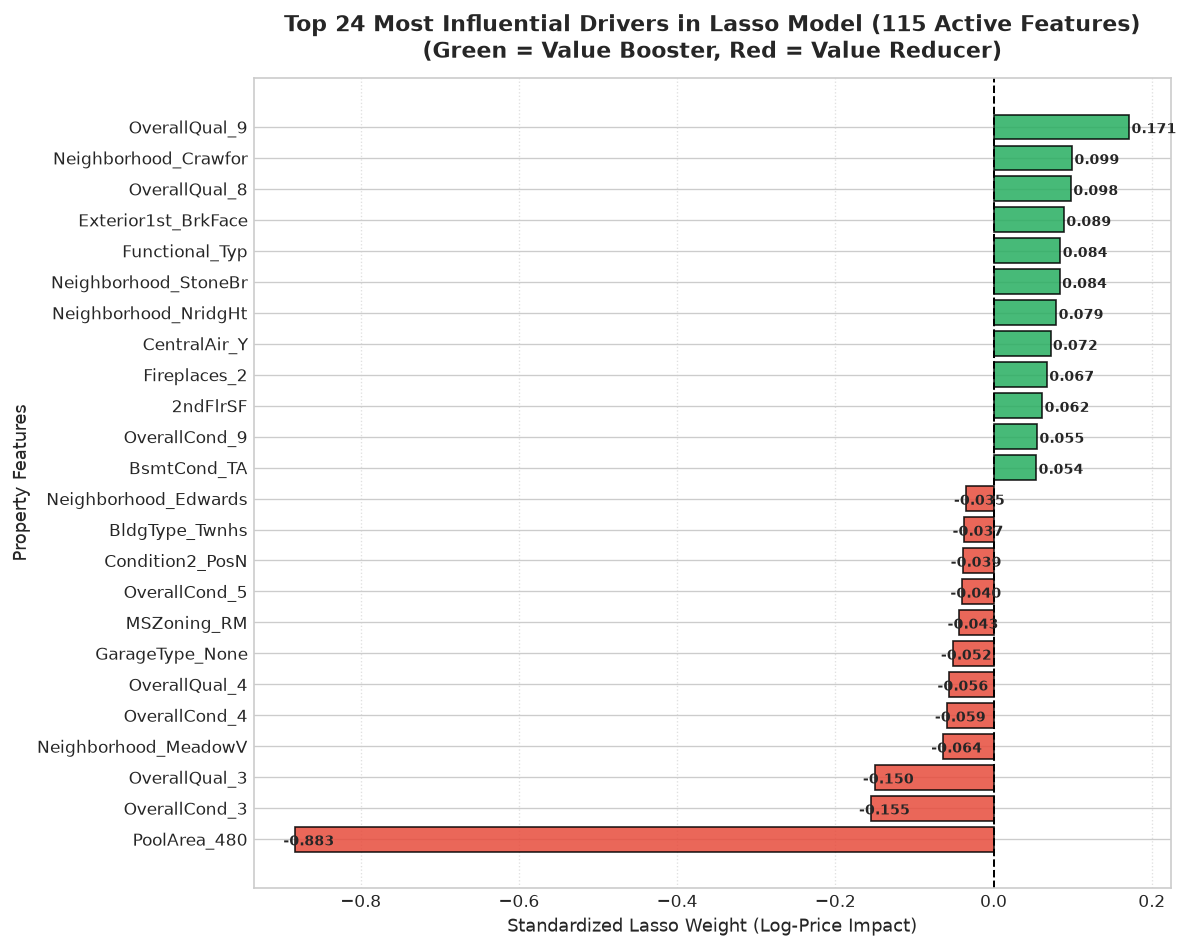

In [10]:
# ==============================================================================
# 📊 STEP 10: LASSO FEATURE SELECTION & INTERPRETABILITY DASHBOARD
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# 1. Feature Weights DataFrame Banayein
lasso_weights_df = pd.DataFrame({
    'Feature': all_names,
    'OLS_Weight': ols_m.coef_,
    'Ridge_Weight': ridge_m.coef_,
    'Lasso_Weight': best_lasso.coef_
})

# 2. Divide into Survivors vs. Eliminated
survivors = lasso_weights_df[lasso_weights_df['Lasso_Weight'] != 0].sort_values(by='Lasso_Weight', ascending=True)
eliminated = lasso_weights_df[lasso_weights_df['Lasso_Weight'] == 0]['Feature'].tolist()

print("=" * 75)
print("✂️ LASSO FEATURE SELECTION AUDIT REPORT")
print("=" * 75)
print(f"Total Features Evaluated     : {len(all_names)}")
print(f"✅ Surviving Features (Active) : {len(survivors)} features")
print(f"❌ Eliminated Noise Features  : {len(eliminated)} features (Zeroed out!)")
print(f"   Sparsity Percentage        : {len(eliminated) / len(all_names) * 100:.1f}%")
print("=" * 75)

# 3. Horizontal Bar Chart (Top 12 Positive & Top 12 Negative Drivers)
top_pos = survivors.tail(12)
top_neg = survivors.head(12)
top_drivers = pd.concat([top_neg, top_pos])

plt.figure(figsize=(10, 8))
colors = ['#27ae60' if w > 0 else '#e74c3c' for w in top_drivers['Lasso_Weight']]

bars = plt.barh(
    top_drivers['Feature'], 
    top_drivers['Lasso_Weight'], 
    color=colors, 
    edgecolor='black', 
    alpha=0.85
)
plt.axvline(0, color='black', linestyle='--', linewidth=1.2)
plt.title(
    f'Top 24 Most Influential Drivers in Lasso Model ({len(survivors)} Active Features)\n(Green = Value Booster, Red = Value Reducer)', 
    fontsize=13, 
    fontweight='bold',
    pad=12
)
plt.xlabel('Standardized Lasso Weight (Log-Price Impact)', fontsize=11)
plt.ylabel('Property Features', fontsize=11)
plt.grid(axis='x', linestyle=':', alpha=0.6)

for bar in bars:
    w = bar.get_width()
    offset = 0.003 if w >= 0 else -0.015
    plt.text(
        w + offset, 
        bar.get_y() + 0.2, 
        f'{w:.3f}', 
        fontsize=8.5, 
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

# 4. Summary Table of Top Positive & Negative Drivers
print("🔍 TOP 5 VALUE BOOSTERS:")
print(survivors.tail(5)[['Feature', 'Lasso_Weight']].sort_values(by='Lasso_Weight', ascending=False).to_string(index=False))

print("\n🔍 TOP 5 VALUE REDUCERS:")
print(survivors.head(5)[['Feature', 'Lasso_Weight']].to_string(index=False))


In [11]:
# ==============================================================================
# 🏭 STEP 11: PRODUCTION PIPELINE SERIALIZATION & LIVE INFERENCE TEST
# ==============================================================================
import joblib
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline

# 1. Master End-to-End Production Pipeline banayein
production_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('lasso', best_lasso)
])

# 2. Fit strictly on Raw X_tr and Log-transformed Target y_tr
production_pipeline.fit(X_tr, y_tr)

# 3. Model ko Disk par save karein (.joblib)
model_dir = Path('production_models')
model_dir.mkdir(parents=True, exist_ok=True)
model_path = model_dir / 'house_price_lasso_pipeline.joblib'

joblib.dump(production_pipeline, model_path)

print("=" * 70)
print("🏭 ENTERPRISE PRODUCTION ARTIFACT SUMMARY")
print("=" * 70)
print(f"✅ Full Production Pipeline Saved: {model_path}")
print(f"   Artifact File Size           : {model_path.stat().st_size / 1024:.2f} KB")
print("=" * 70)

# 4. Live Smoke Test: Ek Unseen Ghar par Live Inference
loaded_pipeline = joblib.load(model_path)
sample_house = X_te.iloc[0:1]

# Model se predict karein (Log scale -> Real $ mein invert)
pred_log_price = loaded_pipeline.predict(sample_house)[0]
predicted_dollars = np.expm1(pred_log_price)
actual_dollars = np.expm1(y_te.iloc[0])

print("\n🧪 LIVE REAL-TIME HOUSE VALUATION TEST (1 HOUSE):")
print("-" * 55)
print(f"   • Overall Quality (1-10)   : {sample_house['OverallQual'].values[0]}")
print(f"   • GrLivArea (Living Area)  : {sample_house['GrLivArea'].values[0]:,} sqft")
print(f"   • Year Built               : {sample_house['YearBuilt'].values[0]}")
print(f"   • Neighborhood             : {sample_house['Neighborhood'].values[0]}")
print("-" * 55)
print(f"   🎯 Model Predicted Price   : ${predicted_dollars:,.0f}")
print(f"   🏷️ Actual Selling Price    : ${actual_dollars:,.0f}")
diff = abs(predicted_dollars - actual_dollars)
print(f"   📊 Valuation Difference    : ${diff:,.0f} ({diff/actual_dollars*100:.1f}%)")
print("=" * 70)


======================================================================\n🏭 ENTERPRISE PRODUCTION ARTIFACT SUMMARY\n======================================================================\n✅ Full Production Pipeline Saved: production_models/house_price_lasso_pipeline.joblib\n   Artifact File Size           : 22.97 KB\n======================================================================\n\n🧪 LIVE REAL-TIME HOUSE VALUATION TEST (1 HOUSE):\n-------------------------------------------------------\n   • Overall Quality (1-10)   : 6\n   • GrLivArea (Living Area)  : 1,068 sqft\n   • Year Built               : 1963\n   • Neighborhood             : Sawyer\n-------------------------------------------------------\n   🎯 Model Predicted Price   : $147,599\n   🏷️ Actual Selling Price    : $154,500\n   📊 Valuation Difference    : $6,901 (4.5%)\n======================================================================\n